In [1]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv to zomato.csv


In [2]:
import pandas as pd
df = pd.read_csv('zomato.csv')
print(df.shape)
df.head()

(51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.info()
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [4]:
df = df.drop(columns=['url', 'address', 'phone', 'reviews_list', 'menu_item', 'dish_liked'])

df = df.rename(columns={
    'approx_cost(for two people)': 'approx_cost',
    'listed_in(type)': 'type',
    'listed_in(city)': 'city',
    'rate': 'rating'
})

df['rating'] = df['rating'].astype(str).str.replace('/5', '', regex=False)
df['rating'] = df['rating'].replace(['NEW', '-', 'nan'], None)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Step 6d: Clean 'approx_cost' (remove commas, convert to number)
df['approx_cost'] = df['approx_cost'].astype(str).str.replace(',', '', regex=False)
df['approx_cost'] = pd.to_numeric(df['approx_cost'], errors='coerce')

df['rating'] = df['rating'].fillna(df['rating'].median())
df['approx_cost'] = df['approx_cost'].fillna(df['approx_cost'].median())
df = df.dropna(subset=['location', 'rest_type', 'cuisines'])

df = df.drop_duplicates()

print(df.shape)
print(df.isnull().sum())
df.head()

(51358, 11)
name            0
online_order    0
book_table      0
rating          0
votes           0
location        0
rest_type       0
cuisines        0
approx_cost     0
type            0
city            0
dtype: int64


,name,online_order,book_table,rating,votes,location,rest_type,cuisines,approx_cost,type,city
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


In [5]:
import numpy as np

for col in ['votes', 'approx_cost']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers, range kept [{lower:.0f}, {upper:.0f}]")

    df[col] = np.clip(df[col], lower, upper)

df.to_csv('zomato_cleaned.csv', index=False)
print("\nCleaned file saved. Final shape:", df.shape)

from google.colab import files
files.download('zomato_cleaned.csv')

votes: 6899 outliers, range kept [-281, 487]
approx_cost: 4740 outliers, range kept [-225, 1175]

Cleaned file saved. Final shape: (51358, 11)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

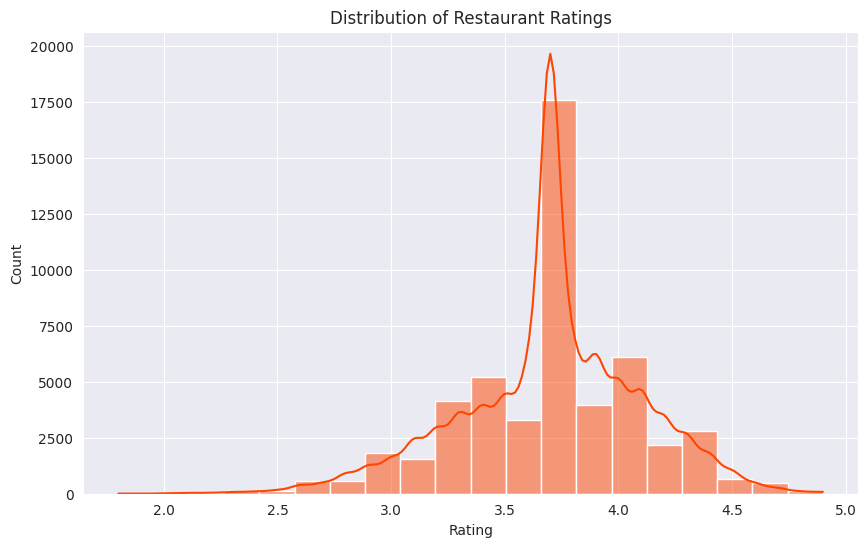

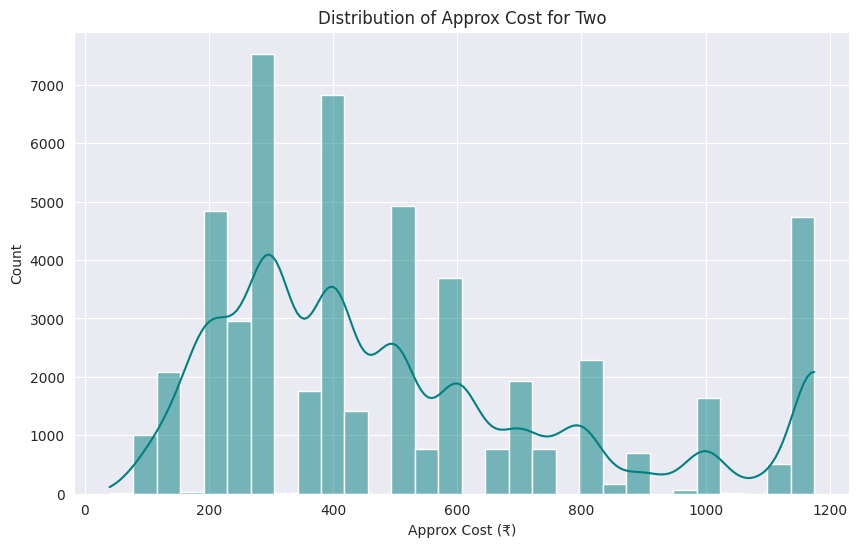

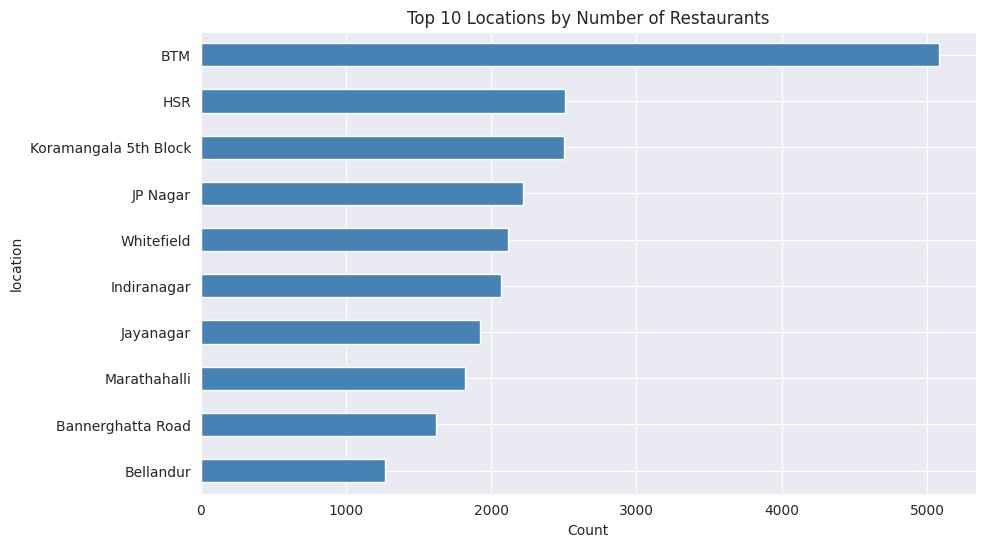

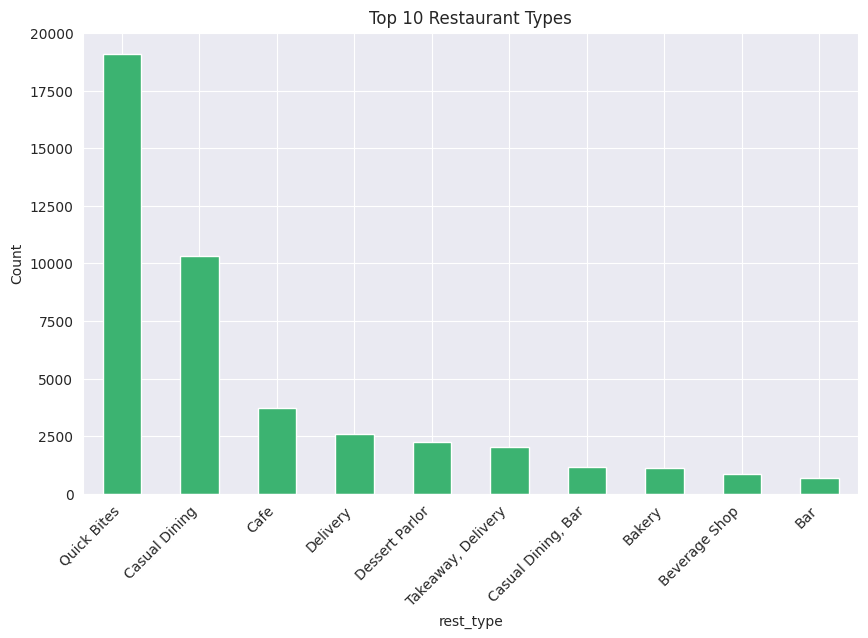

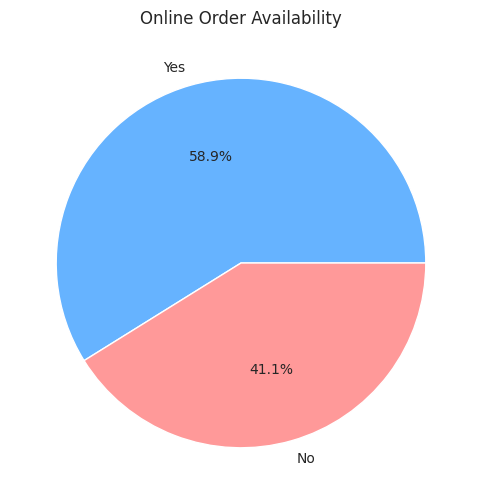

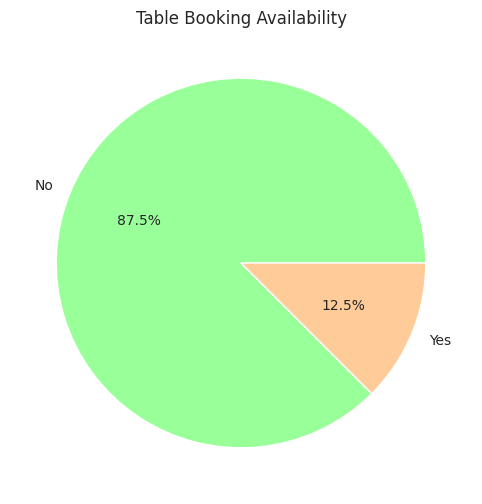

/tmp/ipykernel_2630/71581039.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='rating', palette='Set2')


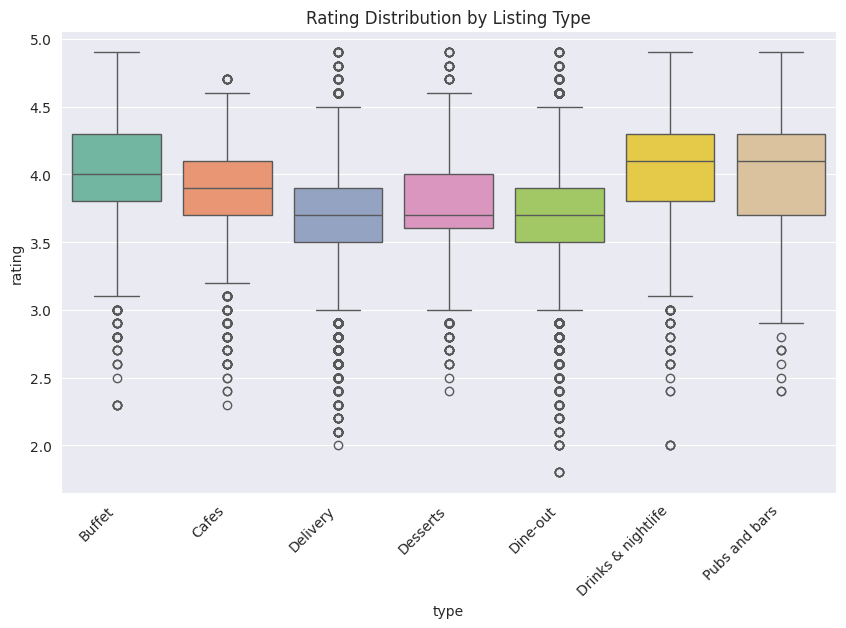

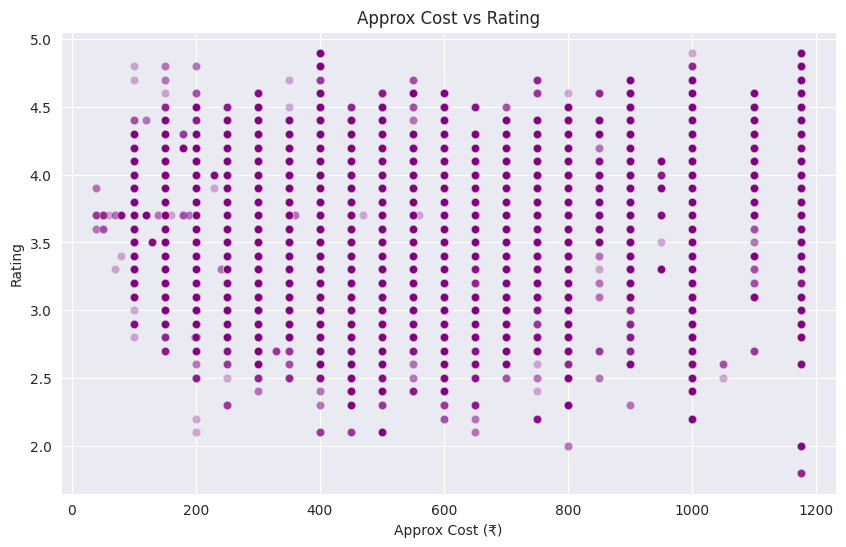

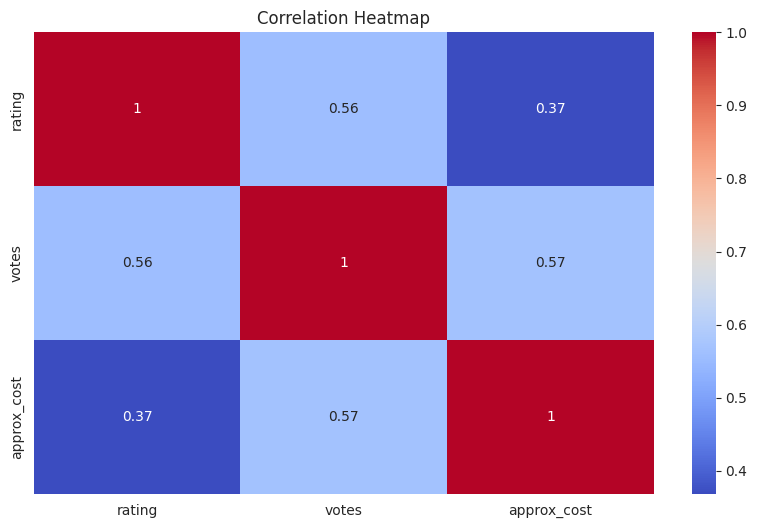

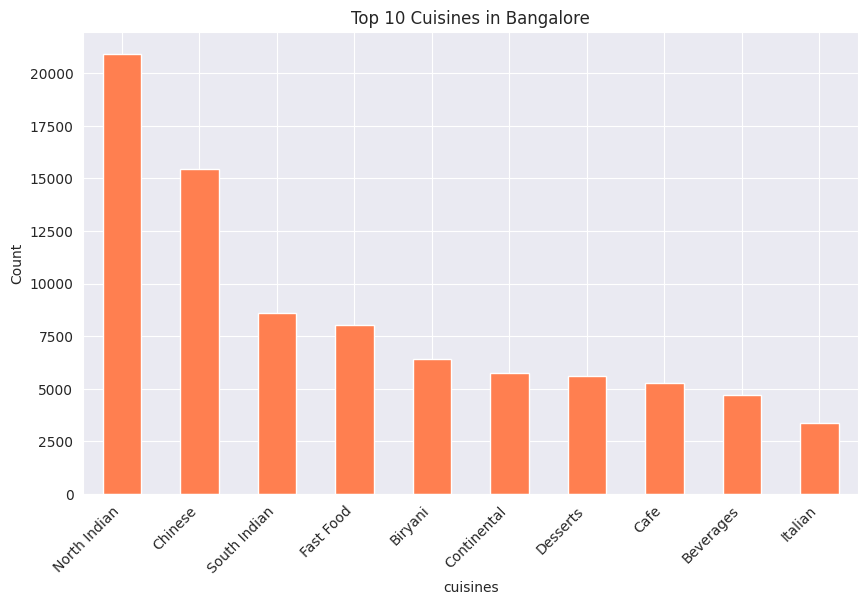

/tmp/ipykernel_2630/71581039.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_voted, y='name', x='votes', palette='rocket')


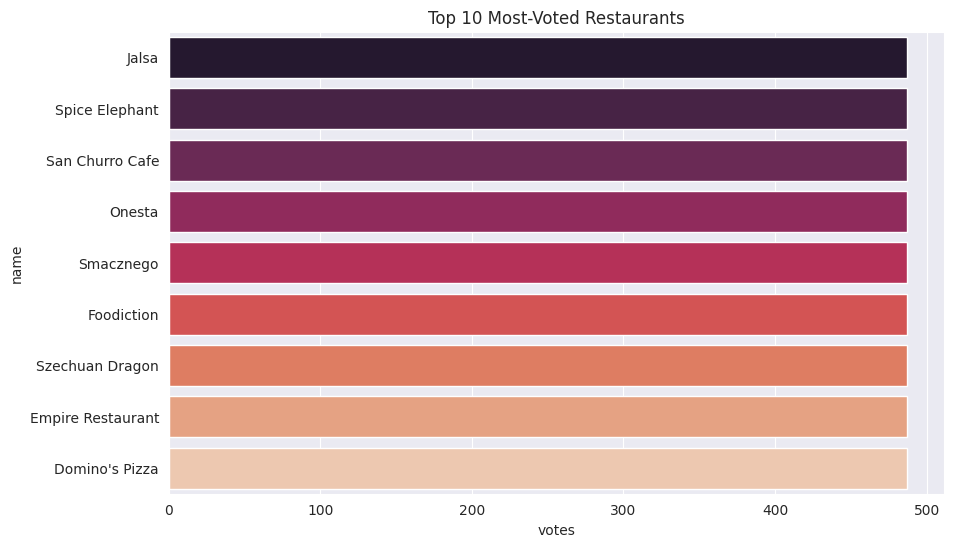

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

plt.figure()
sns.histplot(df['rating'], bins=20, kde=True, color='orangered')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.show()

plt.figure()
sns.histplot(df['approx_cost'], bins=30, kde=True, color='teal')
plt.title('Distribution of Approx Cost for Two')
plt.xlabel('Approx Cost (₹)')
plt.show()

plt.figure()
df['location'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

plt.figure()
df['rest_type'].value_counts().head(10).plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Restaurant Types')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure()
df['online_order'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Online Order Availability')
plt.ylabel('')
plt.show()

plt.figure()
df['book_table'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#99ff99','#ffcc99'])
plt.title('Table Booking Availability')
plt.ylabel('')
plt.show()

plt.figure()
sns.boxplot(data=df, x='type', y='rating', palette='Set2')
plt.title('Rating Distribution by Listing Type')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure()
sns.scatterplot(data=df, x='approx_cost', y='rating', alpha=0.3, color='purple')
plt.title('Approx Cost vs Rating')
plt.xlabel('Approx Cost (₹)')
plt.ylabel('Rating')
plt.show()

plt.figure()
sns.heatmap(df[['rating', 'votes', 'approx_cost']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

plt.figure()
top_cuisines = df['cuisines'].str.split(', ').explode().value_counts().head(10)
top_cuisines.plot(kind='bar', color='coral')
plt.title('Top 10 Cuisines in Bangalore')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure()
top_voted = df.nlargest(10, 'votes')[['name', 'votes']]
sns.barplot(data=top_voted, y='name', x='votes', palette='rocket')
plt.title('Top 10 Most-Voted Restaurants')
plt.show()

In [7]:
print("Top 5 locations:\n", df['location'].value_counts().head(5))
print("\nTop 5 restaurant types:\n", df['rest_type'].value_counts().head(5))
print("\nTop 5 cuisines:\n", df['cuisines'].str.split(', ').explode().value_counts().head(5))
print("\nOnline order %:\n", df['online_order'].value_counts(normalize=True)*100)
print("\nBook table %:\n", df['book_table'].value_counts(normalize=True)*100)
print("\nAvg rating:", df['rating'].mean().round(2))
print("Avg cost for two:", df['approx_cost'].mean().round(0))
print("\nCorrelation matrix:\n", df[['rating','votes','approx_cost']].corr())

Top 5 locations:
 location
BTM                      5082
HSR                      2509
Koramangala 5th Block    2502
JP Nagar                 2221
Whitefield               2116
Name: count, dtype: int64

Top 5 restaurant types:
 rest_type
Quick Bites       19093
Casual Dining     10305
Cafe               3727
Delivery           2591
Dessert Parlor     2259
Name: count, dtype: int64

Top 5 cuisines:
 cuisines
North Indian    20919
Chinese         15431
South Indian     8615
Fast Food        8053
Biryani          6427
Name: count, dtype: int64

Online order %:
 online_order
Yes    58.857432
No     41.142568
Name: proportion, dtype: float64

Book table %:
 book_table
No     87.507302
Yes    12.492698
Name: proportion, dtype: float64

Avg rating: 3.7
Avg cost for two: 512.0

Correlation matrix:
                rating     votes  approx_cost
rating       1.000000  0.555898     0.368013
votes        0.555898  1.000000     0.567888
approx_cost  0.368013  0.567888     1.000000
